# Detecting correlations in time delayed signals

There is a signal $S_1$ that is composed of values of 0 or 1. The signal is generated by processing a different raw signal $S_1'$, for example, to determine whether there is a changepoint or whether the raw signal has crossed a threshold. It is expected that $S_1$ has many more 0s than 1s.

A second signal $S_2$ is also composed of values of 0 or 1 and it, too, is constructed by processing a raw signal $S_2'$. The events (1s) in $S_2$ could be due to:

1. Background noise; or
2. An event caused by $S_1$.

The occurrence of an event in $S_1$ doesn't guarantee there will be associated event in $S_2$. Also, if an event in $S_1$ occurs at index $t$, then the corresponding event in $S_2$ will occur at or after $t$, i.e. there could be a delay, albeit a limited one.

The data is modelled as follows:

1. There is a background noise rate $\theta$. It is assumed to have a prior probability given by a uniform distribution with hyper-parameters $\theta_{min}$ and $\theta_{max}$ so that $\theta \sim \text{Uniform}(\theta_{min}, \theta_{max})$.
2. The probability that an event in $S_1$ leads to a corresponding event in $S_2$ is denoted $\phi$, where $\phi \sim \text{Uniform}(\phi_{min}, \phi_{max})$.
3. To allow for a considerable flexibility in the delay between an event in $S_1$ and $S_2$, the delay distribution will be modelled as a categorical distribution with a Dirichlet prior. The delay distribution is denoted $d$ and it is drawn from a Dirichlet distribution with a prior of $\alpha$. The probabilities in the vector $d$ must sum to 1.

The problem is to infer $\theta$, $\phi$ and $d$ given signals $S_1$ and $S_2$ and the Metropolis-Hastings algorithm is used to infer those probabilities. Cruically, the value of $\phi$ provides a measure of how causally related $S_2$ is to $S_1$.

In [1]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import random

from scipy import stats

In [2]:
def generate_signal1(n_timesteps: int, n_ones: int) -> np.ndarray:
    """Generate signal 1."""

    assert n_ones <= n_timesteps

    s1 = np.zeros(n_timesteps)
    for idx in random.sample(range(n_timesteps), n_ones):
        s1[idx] = 1

    return s1

In [3]:
def categorical(p: np.ndarray) -> int:
    """Generate a sample from a categorical distribution."""

    return int(np.argmax(stats.multinomial.rvs(n=1, p=p)))

In [4]:
def uniform(min_value: float, max_value: float) -> float:
    """Sample from a uniform distribution."""
    
    assert min_value < max_value
    v = float(stats.uniform.rvs(min_value, max_value-min_value))

    assert min_value <= v <= max_value
    return v

In [5]:
def generate_signal2(signal1: np.ndarray, theta: float, phi: float, d: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Generate signal 2."""

    assert 0.0 <= theta <= 1.0
    assert 0.0 <= phi <= 1.0

    # Generate signal 2 based on the background alone
    s2 = stats.bernoulli.rvs(p=theta, size=len(signal1))
    background = copy.deepcopy(s2)

    # Add in samples due to signal 1
    for i in range(len(signal1)):
        if signal1[i] == 1 and stats.bernoulli.rvs(phi) == 1:
            delay = categorical(d)
            if i + delay < len(signal1):
                s2[i+delay] = 1

    return s2, background

In [6]:
theta_min = 0.0
theta_max = 0.03

phi_min = 0.0
phi_max = 1.0

theta = 0.002 #uniform(theta_min, theta_max)
phi = 0.95 #uniform(phi_min, phi_max)
max_delay = 4
alpha = np.ones(max_delay)
d = stats.dirichlet.rvs(alpha)[0]

print(f"theta = {theta}")
print(f"phi = {phi}")
print(f"alpha = {alpha}")
print(f"d = {d}")

s1 = generate_signal1(1000, 5)
s2, background = generate_signal2(s1, theta, phi, d)

theta = 0.002
phi = 0.95
alpha = [1. 1. 1. 1.]
d = [0.19386871 0.58161493 0.08346499 0.14105136]


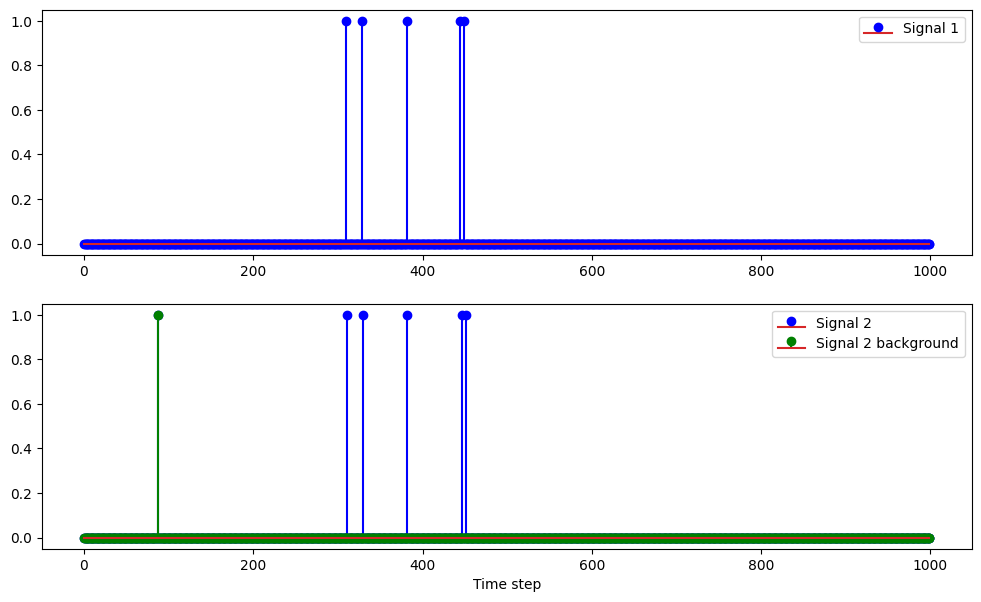

In [7]:
fig = plt.figure(figsize=(12,7))
plt.subplot(211)
plt.stem(s1, 'b', label='Signal 1')
plt.legend()
plt.subplot(212)
plt.stem(s2, 'b', label='Signal 2')
plt.stem(background, 'g', label='Signal 2 background')
plt.legend()
plt.xlabel('Time step')
plt.show()

In [8]:
def noisy_or(probs):
    """Noisy OR where p = 1 - (1-p_0)(1-p_1) ... (1-p_{N-1})."""
    return float(1 - np.exp(np.sum([np.log(1 - p) for p in probs])))

In [9]:
def log_likelihood(s1, s2, d, theta, phi, theta_min, theta_max, phi_min, phi_max, alpha):

    if theta < theta_min or theta > theta_max:
        return -np.inf
    
    if phi < phi_min or phi > phi_max:
        return -np.inf
    
    N = len(s1)

    # Background
    v = [[theta] for _ in range(N)]

    # Occurrences due to signal 1
    for i in range(N):
        if s1[i] != 1:
            continue
            
        for j in range(len(d)):
            if i+j < N:
                v[i+j].append(phi * d[j])
    
    # Combine
    for i in range(N):
        v[i] = noisy_or(v[i])
        assert 0 <= v[i] <= 1

    # Calculate the log likelihood
    total = 0
    for i in range(N):
        if s2[i] == 0:
            total += np.log(1 - v[i])
        else:
            total += np.log(v[i])

    # Add on the priors to the log probability
    total += np.log(1/(theta_max - theta_min)) + \
        np.log(1/(phi_max - phi_min)) + \
        np.log(stats.dirichlet.pdf(d, alpha))

    return total

The code in the following cell implements the Metropolis-Hastings algorithm. The acceptance probability is given by

$$
A = \min \Big( 1, \frac{p(x^*)}{p(x)} \frac{q(x|x^*)}{q(x^*|x)} \Big)
$$

where $x^*$ is the proposed value of $x$.

In [10]:
def bayesian_inference(alpha: np.ndarray, 
                       theta_min: float, 
                       theta_max: float, 
                       phi_min: float, 
                       phi_max: float, 
                       s1: np.ndarray, 
                       s2: np.ndarray,
                       n_samples: int):
    """Perform Bayesian inference to determine d, theta and phi."""

    assert len(alpha) > 0
    assert 0.0 <= theta_min < theta_max <= 1.0
    assert 0.0 <= phi_min < phi_max <= 1.0
    assert len(s1) == len(s2)
    assert 0 < n_samples

    # Initial estimates
    d = [stats.dirichlet.rvs(alpha)[0]]
    theta = [uniform(theta_min, theta_max)]
    phi = [uniform(phi_min, phi_max)]

    p = np.exp(log_likelihood(s1, s2, d[0], theta[0], phi[0], theta_min, theta_max, phi_min, phi_max, alpha))

    # Proposal standard deviations
    k = 100
    theta_sigma = 0.05
    phi_sigma = 0.1

    n_accepted = 0

    for i in range(n_samples):

        # Generate the proposals for each variable
        d_star = stats.dirichlet.rvs(k * (0.00001 + d[-1]))[0]
        if any(d_star == 0):
            raise ValueError(f"Unable to perturb Dirichlet prior correctly: {d[-1]}")

        theta_star = np.random.normal(theta[i-1], theta_sigma)
        phi_star = np.random.normal(phi[i-1], phi_sigma)
        
        # Calculate the likelihood given the proposals
        p_star = np.exp(log_likelihood(s1, s2, d_star, theta_star, phi_star, theta_min, theta_max, phi_min, phi_max, alpha))

        # There's a good description of how to calculate the acceptance probability with
        # asymmetric distributions here: https://blog.djnavarro.net/posts/2023-04-12_metropolis-hastings
        q_x_given_x_star = stats.dirichlet.pdf(d[-1], d_star)
        q_x_star_given_x = stats.dirichlet.pdf(d_star, d[-1])

        # Calculate the acceptance probability
        acceptance_prob = min(1, (p_star*q_x_given_x_star)/(p*q_x_star_given_x))
        u = np.random.uniform(0, 1)

        if u > acceptance_prob:
            d.append(d[i-1])  # Reject the proposal
            theta.append(theta[i-1])
            phi.append(phi[i-1])
        else:
            d.append(d_star)  # Accept the proposal
            theta.append(theta_star)
            phi.append(phi_star)
            p = p_star
            n_accepted += 1

    return d, theta, phi, n_accepted/n_samples

In [11]:
d_est, theta_est, phi_est, p_accepted = bayesian_inference(alpha, 
                                               theta_min, theta_max, 
                                               phi_min, phi_max, 
                                               s1, s2,
                                               n_samples=100000)
print(f"Proportion accepted: {p_accepted}")

Proportion accepted: 0.02186


In [12]:
def subsample(samples, n: int):
    """Retain every n samples."""
    return [s for i,s in enumerate(samples) if i%n == 0]

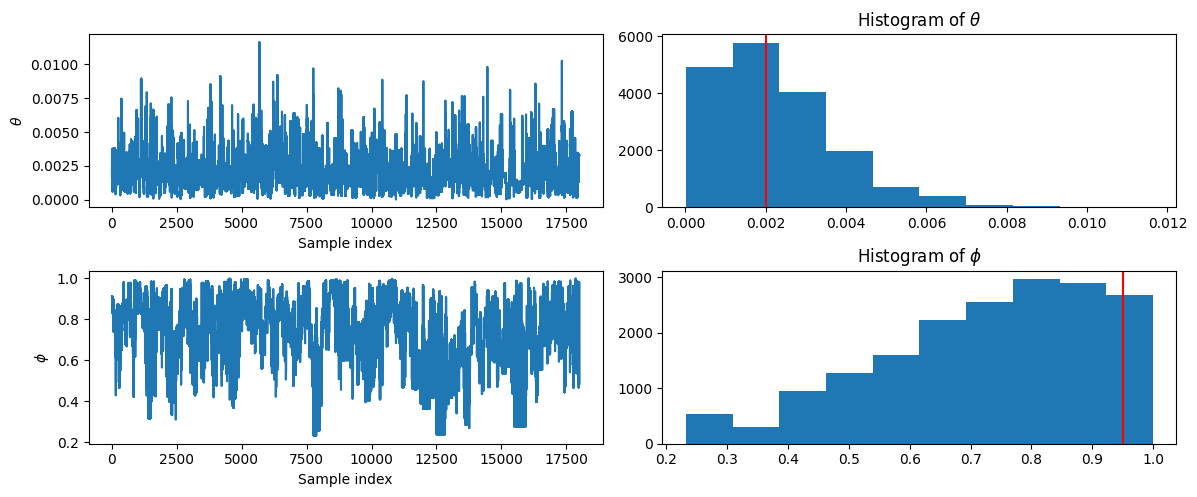

In [13]:
burnin = 10000
lag = 5

theta_est_retained = subsample(theta_est[burnin:], lag)
phi_est_retained = subsample(phi_est[burnin:], lag)

fig = plt.figure(figsize=(12,7))
plt.subplot(321)
plt.plot(theta_est_retained)
plt.xlabel('Sample index')
plt.ylabel('$\\theta$')

plt.subplot(322)
plt.hist(theta_est_retained)
plt.axvline(theta, color='r')
plt.title('Histogram of $\\theta$')

plt.subplot(323)
plt.plot(phi_est_retained)
plt.xlabel('Sample index')
plt.ylabel('$\\phi$')

plt.subplot(324)
plt.hist(phi_est_retained)
plt.axvline(phi, color='r')
plt.title('Histogram of $\\phi$')

plt.tight_layout()
plt.show()

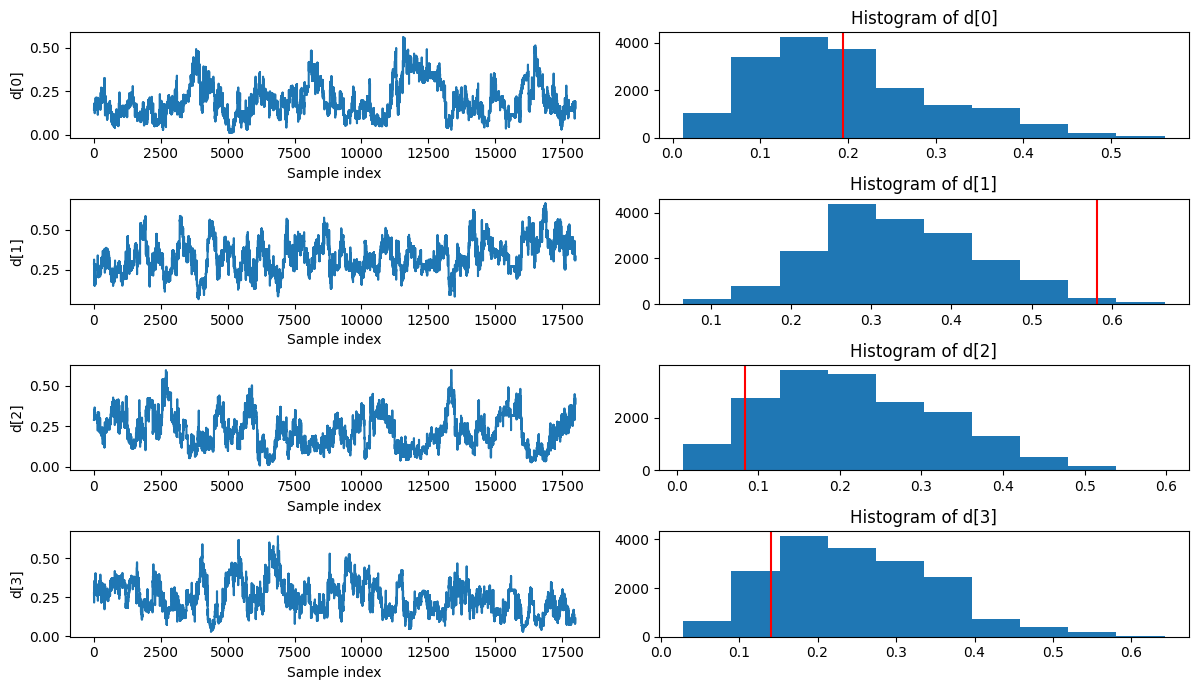

In [ ]:
d_est_matrix = np.array(d_est)[burnin:]

fig = plt.figure(figsize=(12,7))
for i in range(len(alpha)):
    plt.subplot(len(alpha), 2, 2*i+1)
    plt.plot(d_est_matrix[:,i][0::lag])
    plt.ylabel(f'd[{i}]')
    plt.xlabel('Sample index')

    plt.subplot(len(alpha), 2, 2*i+2)
    plt.hist(d_est_matrix[:,i][0::lag])
    plt.axvline(d[i], color='r')
    plt.title(f'Histogram of d[{i}]')

plt.tight_layout()
plt.show()